<a href="https://www.kaggle.com/code/gonnzaga/summit-dupla-intelig-ncia-artificial?scriptVersionId=352703173" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Classificação de tipos de vidro com SVM (Glass Identification Dataset)

**Curso:** Engenharia de Software<br>
**Matéria:** Inteligência Artificial<br>
**Professor:** Fabiano Menegidio e Higor Barreto<br>
**Turma:** 6B - Noturno<br>

**Victor Gabriel Figueira Gonzaga RGM:11241100198**<br>
**Paulo Vinicius Neves Macedo RGM:11241103437**<br>

 
Este notebook segue as etapas solicitadas:
 
1. Import do dataset para o Kaggle pessoal

2. Avaliação do banco de dados

3. Tratativa de dados ausentes

4. Tratativa de encoding, quando necessário

5. Divisão dos dados de treino e teste

6. Aplicação do GridSearchCV e treino do modelo

7. Avaliação final do modelo (F1-score, relatório de classificação e matriz de confusão)

8. Importância das features utilizadas pelo modelo

9. Escrita do modelo — conclusão
 

In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

## 1. Import do dataset para o Kaggle pessoal
 
O dataset **Glass Classification** (`uciml/glass`), do repositório UCI, foi adicionado ao notebook pelo painel **Input** do Kaggle, ficando disponível na pasta `/kaggle/input`.
 
A célula abaixo é a célula padrão do ambiente Kaggle. Ela percorre a pasta `/kaggle/input` e lista os arquivos disponíveis, o que permite confirmar que o dataset foi importado corretamente e descobrir o caminho do arquivo `glass.csv`.

### 1.2 Leitura do arquivo CSV
 
Leitura do arquivo `glass.csv` com o `pd.read_csv()` e exibição das cinco primeiras linhas com `df.head()`. O dataset contém nove atributos numéricos (índice de refração `RI` e teores de `Na`, `Mg`, `Al`, `Si`, `K`, `Ca`, `Ba` e `Fe`) e a coluna `Type`, que representa o tipo de vidro e é a variável alvo da classificação.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/uciml/glass/glass.csv")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## 2. Avaliação do banco de dados
 
### 2.1 Estrutura do dataset
 
Uso do `df.info()` para inspecionar a estrutura dos dados: quantidade de registros, nome das colunas, contagem de valores não nulos e tipo de cada coluna.
 
O conjunto possui 214 registros e 10 colunas, todas com 214 valores não nulos. Os nove atributos são do tipo `float64` e a variável alvo `Type` é do tipo `int64`.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


### 2.2 Estatísticas descritivas
 
Uso do `df.describe()` para obter média, desvio padrão, mínimo, quartis e máximo de cada coluna.
 
Observa-se que o silício (`Si`) é o componente predominante (média de 72,65), que o bário (`Ba`) está ausente em mais de 75% das amostras e que variáveis como `K` e `Ca` apresentam possíveis outliers. As escalas dos atributos são muito diferentes entre si, o que justifica a padronização dos dados antes do treinamento do SVM.

In [4]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


## 3. Tratativa de dados ausentes
 
### 3.1 Verificação de valores nulos e linhas duplicadas
 
A célula abaixo conta os valores nulos de cada coluna com `df.isnull().sum()` e as linhas duplicadas com `df.duplicated().sum()`. Caso exista algum valor ausente, o código preenche a coluna com a mediana, medida pouco sensível a outliers.
 
Resultado: nenhuma coluna possui valores ausentes, portanto nenhuma imputação foi necessária. Foi identificada 1 linha duplicada no conjunto.

In [5]:
# Tratativa de dados ausentes
print('Valores nulos por coluna:')
print(df.isnull().sum())

print('\nLinhas duplicadas:', df.duplicated().sum())

# Caso existam nulos (o Glass Dataset original geralmente não tem),
# tratamos com imputação pela mediana das colunas numéricas:
if df.isnull().sum().sum() > 0:
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
    print('Valores ausentes tratados com a mediana.')
else:
    print('Nenhum valor ausente encontrado no dataset.')

Valores nulos por coluna:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Linhas duplicadas: 1
Nenhum valor ausente encontrado no dataset.


## 4. Tratativa de encoding
 
Todos os atributos de entrada já são numéricos (`float64`), portanto não é necessário aplicar encoding nas variáveis preditoras.
 
A variável alvo `Type` também é numérica, mas suas classes não são sequenciais: existem os tipos 1, 2, 3, 5, 6 e 7, sem nenhuma amostra do tipo 4. Por isso foi aplicado o `LabelEncoder`, que converte as classes para uma sequência contínua de 0 a 5, armazenada na nova coluna `Type_encoded`. A célula também exibe a correspondência entre a classe original e a classe codificada.

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])

print('Classes originais -> classes codificadas:')
for original, encoded in zip(le.classes_, range(len(le.classes_))):
    print(f'  Type {original} -> {encoded}')

Classes originais -> classes codificadas:
  Type 1 -> 0
  Type 2 -> 1
  Type 3 -> 2
  Type 5 -> 3
  Type 6 -> 4
  Type 7 -> 5


## Complemento da etapa 2: análise visual do banco de dados
 
### 2.3 Distribuição das classes
 
Complemento da avaliação do banco de dados, agora de forma visual. O gráfico de barras mostra a quantidade de amostras de cada tipo de vidro e permite verificar se as classes estão desbalanceadas, o que influencia a interpretação das métricas do modelo.

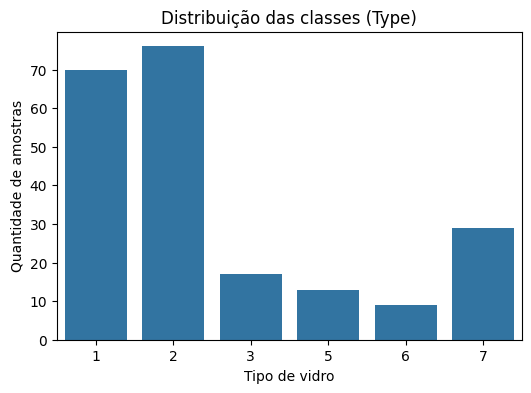

In [7]:
# Distribuição das classes (desbalanceamento é comum nesse dataset)
plt.figure(figsize=(6,4))
sns.countplot(x='Type', data=df, order=sorted(df['Type'].unique()))
plt.title('Distribuição das classes (Type)')
plt.xlabel('Tipo de vidro')
plt.ylabel('Quantidade de amostras')
plt.show()

### 2.4 Correlação entre os atributos
 
Mapa de calor com a correlação entre os nove atributos numéricos. As colunas `Type` e `Type_encoded` são retiradas do cálculo por representarem a classe. Valores próximos de 1 ou de -1 indicam forte relação linear entre dois atributos, e valores próximos de 0 indicam pouca relação.

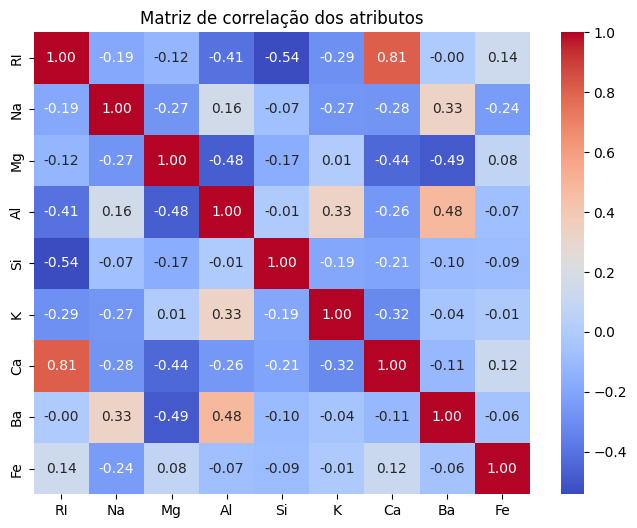

In [8]:
# Correlação entre os atributos numéricos
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns=['Type', 'Type_encoded']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlação dos atributos')
plt.show()

## 5. Divisão dos dados de teste e treino

Separação do dataset em treino (80%) e teste (20%) usando `train_test_split`. O parâmetro `stratify=y` mantém a proporção de cada tipo de vidro nos dois conjuntos, o que é importante porque as classes estão desbalanceadas (visto no gráfico da seção 2.3).

As features (`X`) são as 9 colunas químicas originais; o alvo (`y`) é `Type_encoded`, já que o SVM trabalha melhor com classes numeradas de forma contínua.

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Type', 'Type_encoded'])
y = df['Type_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Treino:', X_train.shape, ' Teste:', X_test.shape)

Treino: (171, 9)  Teste: (43, 9)


### 5.1 Padronização dos atributos

Como visto na seção 2.2, os atributos estão em escalas bem diferentes (ex.: `Si` na casa de 70, `Ba` perto de 0). O SVM é sensível a essa diferença de escala, então aplicamos o `StandardScaler`, ajustando-o apenas nos dados de treino (`fit_transform`) e reaplicando no teste (`transform`), para evitar vazamento de informação do teste para o treino.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Aplicação do GridSearchCV e treino do modelo

Busca dos melhores hiperparâmetros do SVM (`C`, `gamma` e `kernel`) usando `GridSearchCV` com validação cruzada de 5 folds.

Como o dataset é desbalanceado (seção 2.3), a métrica de otimização não é a acurácia (`scoring='accuracy'`), pois ela tende a favorecer combinações de hiperparâmetros que acertam bem as classes majoritárias (Type 1 e Type 2) e ignoram o desempenho nas classes minoritárias. Em vez disso, usamos `scoring='f1_weighted'`, que calcula o F1-score de cada classe individualmente e faz a média ponderada pelo número de amostras — penalizando combinações de hiperparâmetros que têm bom desempenho geral às custas das classes menores.

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)

print('Melhores hiperparâmetros:', grid.best_params_)
print('Melhor F1-score ponderado (CV):', grid.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Melhores hiperparâmetros: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Melhor F1-score ponderado (CV): 0.6755358202468177


### 6.1 Treino do modelo final

Com os melhores hiperparâmetros encontrados, treinamos o modelo definitivo com os dados de treino já padronizados. Esse será o modelo avaliado na Etapa 3, com os dados de teste.

In [12]:
best_model = grid.best_estimator_
best_model.fit(X_train_scaled, y_train)

SVC(C=100, gamma='auto')

## 7. Avaliação final do modelo

Etapa final da atividade: o modelo `best_model`, treinado na seção 6 com os hiperparâmetros que maximizam o **F1-score ponderado** (e não a acurácia), é testado agora nos dados que ele nunca viu (`X_test_scaled`).

### 7.1 Predições e F1-score

Como orientado, a métrica principal de avaliação é o **F1-score**, e não a acurácia — em um dataset desbalanceado como este, a acurácia pode mascarar o fato de o modelo ignorar completamente uma classe minoritária (ver seção 7.2, Type 3) enquanto ainda apresenta um número geral aparentemente bom.

Calculamos duas versões do F1-score:
- **F1 macro**: média simples do F1 de cada classe, tratando todas as classes com o mesmo peso — é a versão mais sensível ao desbalanceamento, pois uma classe minoritária com desempenho ruim (Type 3) pesa tanto quanto uma classe majoritária.
- **F1 ponderado (weighted)**: média do F1 de cada classe, ponderada pelo número de amostras de cada uma — reflete melhor o desempenho "geral" do modelo, mas ainda assim não esconde totalmente as classes minoritárias, como a acurácia faria.

In [13]:
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test_scaled)

f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
acuracia = accuracy_score(y_test, y_pred)

print(f'F1-score (macro):     {f1_macro:.4f}')
print(f'F1-score (ponderado): {f1_weighted:.4f}')
print(f'Acurácia (referência): {acuracia:.4f}')

F1-score (macro):     0.7717
F1-score (ponderado): 0.7886
Acurácia (referência): 0.7907


### 7.2 Relatório de classificação

Métricas de precisão, recall e f1-score por tipo de vidro, usando `le.classes_` para mostrar os rótulos originais (1, 2, 3, 5, 6, 7) em vez dos códigos 0-5. O parâmetro `zero_division=0` evita o aviso do sklearn nas classes em que o modelo não fez nenhuma predição (caso do Type 3 neste dataset).

O F1-score de cada classe individual, mostrado na coluna `f1-score` abaixo, é o que efetivamente orienta a leitura dos resultados — e é nele que fica visível o problema do Type 3, que a acurácia geral esconderia.

In [14]:
print(classification_report(
    y_test,
    y_pred,
    target_names=[f'Type {c}' for c in le.classes_],
    zero_division=0
))

              precision    recall  f1-score   support

      Type 1       0.77      0.71      0.74        14
      Type 2       0.80      0.80      0.80        15
      Type 3       0.67      0.67      0.67         3
      Type 5       1.00      1.00      1.00         3
      Type 6       0.50      0.50      0.50         2
      Type 7       0.86      1.00      0.92         6

    accuracy                           0.79        43
   macro avg       0.77      0.78      0.77        43
weighted avg       0.79      0.79      0.79        43



### 7.3 Matriz de confusão

Mostra, para cada tipo real de vidro (linha), quantas amostras o modelo classificou em cada tipo previsto (coluna). A diagonal principal são os acertos; fora da diagonal, os erros.

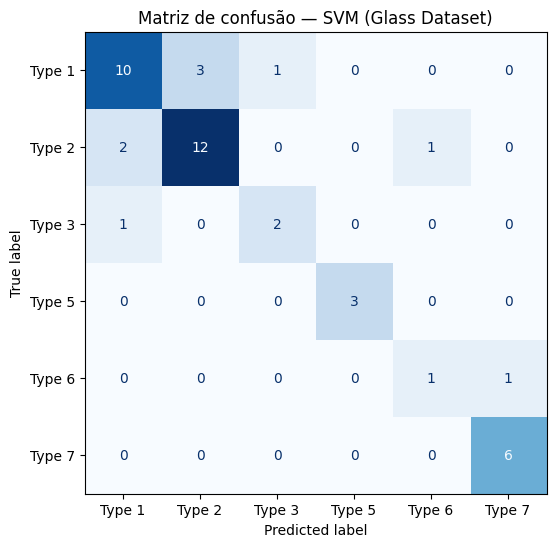

In [15]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Type {c}' for c in le.classes_])

fig, ax = plt.subplots(figsize=(7,6))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title('Matriz de confusão — SVM (Glass Dataset)')
plt.show()

## 8. Importância das features

O SVM (especialmente com kernel `rbf`) não expõe uma importância de atributos "nativa" como acontece em modelos baseados em árvore (ex.: Random Forest). Por isso, para saber quais das 9 composições químicas mais influenciam a decisão do modelo, usamos a técnica de **importância por permutação** (`permutation_importance`), que funciona com qualquer modelo já treinado, independente do algoritmo.

**Como funciona:** para cada feature, o valor dessa coluna é embaralhado aleatoriamente entre as amostras de teste (quebrando a relação entre aquela feature e o resultado), e observa-se o quanto o desempenho do modelo (aqui, o F1-score ponderado, a mesma métrica usada nas seções 6 e 7) cai em relação ao original. Uma queda grande indica que o modelo dependia fortemente daquela feature; uma queda pequena (ou nula) indica que a feature contribui pouco para a decisão. O processo é repetido várias vezes (`n_repeats=30`) para obter uma média e um desvio-padrão mais confiáveis.

In [16]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_test_scaled,
    y_test,
    scoring='f1_weighted',
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

importancias = pd.DataFrame({
    'feature': X.columns,
    'importancia_media': result.importances_mean,
    'importancia_std': result.importances_std
}).sort_values('importancia_media', ascending=False)

importancias

,feature,importancia_media,importancia_std
0,RI,0.225431,0.045794
6,Ca,0.212780,0.073601
3,Al,0.176901,0.049645
2,Mg,0.155331,0.048341
1,Na,0.102608,0.051210
7,Ba,0.084690,0.033969
4,Si,0.081518,0.049589
5,K,0.044837,0.036797
8,Fe,0.018666,0.023985


### 8.1 Gráfico das features mais utilizadas pelo modelo

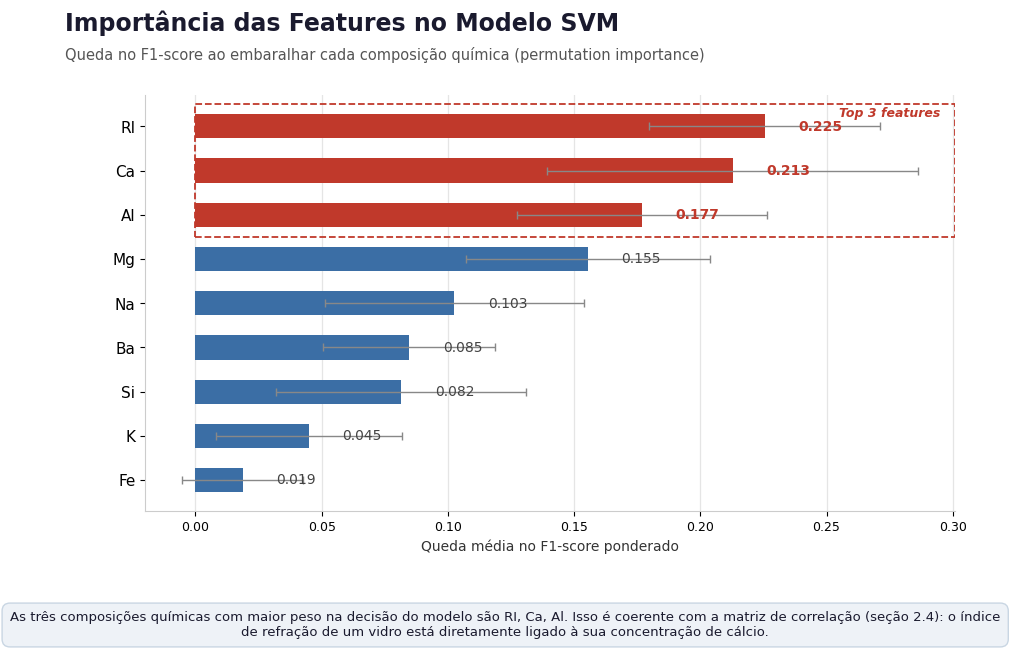

In [17]:
from matplotlib.patches import Rectangle

ordem = importancias.sort_values('importancia_media', ascending=True).reset_index(drop=True)

n_top = 3
cores = ['#c0392b' if i >= len(ordem) - n_top else '#3b6ea5' for i in range(len(ordem))]

fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

barras = ax.barh(
    ordem['feature'],
    ordem['importancia_media'],
    xerr=ordem['importancia_std'],
    color=cores,
    edgecolor='none',
    height=0.55,
    capsize=3,
    error_kw={'ecolor': '#888888', 'elinewidth': 1}
)

for i, (barra, valor) in enumerate(zip(barras, ordem['importancia_media'])):
    destaque = i >= len(ordem) - n_top
    ax.text(
        barra.get_width() + ordem['importancia_std'].max() * 0.18,
        barra.get_y() + barra.get_height() / 2,
        f'{valor:.3f}',
        va='center',
        fontsize=10,
        fontweight='bold' if destaque else 'normal',
        color='#c0392b' if destaque else '#444444'
    )

fig.text(0.06, 0.96, 'Importância das Features no Modelo SVM', fontsize=17, fontweight='bold', color='#1a1a2e')
fig.text(0.06, 0.915, 'Queda no F1-score ao embaralhar cada composição química (permutation importance)', fontsize=10.5, color='#555555')

ax.set_xlabel('Queda média no F1-score ponderado', fontsize=10, color='#333333')
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.grid(axis='x', color='#e5e5e5', linewidth=0.9, zorder=0)
ax.set_axisbelow(True)

# Destaca as 3 features mais importantes, no mesmo espírito do círculo usado em aula para marcar o ponto relevante
top3_y_min = len(ordem) - n_top - 0.5
rect = Rectangle(
    (0, top3_y_min), ax.get_xlim()[1], n_top,
    fill=False, edgecolor='#c0392b', linestyle='--', linewidth=1.3, zorder=3
)
ax.add_patch(rect)
ax.text(
    ax.get_xlim()[1] * 0.98, top3_y_min + n_top - 0.05,
    'Top 3 features',
    ha='right', va='top', fontsize=9, color='#c0392b', fontweight='bold', style='italic'
)

plt.subplots_adjust(top=0.86, bottom=0.22, left=0.14, right=0.95)

top3_nomes = ', '.join(importancias['feature'].head(3).tolist())
texto_caixa = (f"As três composições químicas com maior peso na decisão do modelo são {top3_nomes}. "
               f"Isso é coerente com a matriz de correlação (seção 2.4): o índice de refração de um vidro "
               f"está diretamente ligado à sua concentração de cálcio.")

fig.text(
    0.5, 0.045, texto_caixa,
    ha='center', va='center', fontsize=9.5, color='#1a1a2e', wrap=True,
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#eef2f7', edgecolor='#c9d6e3')
)

plt.show()

**Interpretação:** as barras mais longas correspondem às composições químicas que, quando embaralhadas, causam a maior queda no F1-score — ou seja, são as features que o modelo mais utiliza para diferenciar os tipos de vidro. Features com barra próxima de zero contribuem pouco para a decisão do modelo e poderiam, em princípio, ser removidas sem grande perda de desempenho (embora, com apenas 9 atributos ao todo, essa remoção não seja necessária aqui).

As três features mais importantes para o modelo foram **RI** (índice de refração, queda média de 0.225 no F1), **Ca** (cálcio, 0.213) e **Al** (alumínio, 0.177). Na matriz de correlação (seção 2.4), RI e Ca já se destacavam por sua forte correlação entre si (o índice de refração de um vidro está diretamente ligado à quantidade de cálcio em sua composição), o que é coerente com ambos aparecerem entre as features mais relevantes para o SVM. Já **Fe** (ferro) e **K** (potássio) foram as features menos utilizadas pelo modelo, com quedas médias de apenas 0.019 e 0.045 no F1-score, respectivamente.

## 9. Escrita do modelo — conclusão

**Melhores hiperparâmetros encontrados** (`grid.best_params_`, seção 6, com `scoring='f1_weighted'`): kernel `rbf`, `C = 100`, `gamma = 'auto'`.

**F1-score ponderado (CV)** (`grid.best_score_`, seção 6): 0.6755 (67.55%).

**F1-score no conjunto de teste (seção 7.1):**
- F1 macro: 0.7717 (77.17%)
- F1 ponderado: 0.7886 (78.86%)
- Acurácia (apenas como referência, não como métrica principal): 0.7907 (79.07%)

**Por que o F1-score em vez da acurácia:** o Glass Dataset possui classes fortemente desbalanceadas (seção 2.3) — Type 1 (70 amostras) e Type 2 (76 amostras) concentram a maior parte dos dados, enquanto Type 3 (17), Type 5 (13) e principalmente Type 6 (9) têm poucos exemplos. Nesse cenário, a acurácia pode indicar um desempenho aparentemente bom mesmo que o modelo erre sistematicamente as classes minoritárias, já que elas pesam pouco no total de amostras. O F1-score, por combinar precisão e recall por classe, penaliza esse comportamento — especialmente o F1 macro, que dá o mesmo peso a todas as classes independentemente do tamanho. Vale notar que, ao trocar a métrica de otimização do `GridSearchCV` de acurácia para F1 ponderado, o próprio conjunto de hiperparâmetros selecionado mudou (de `C=1, gamma=0.1` para `C=100, gamma='auto'`), e o modelo resultante teve desempenho melhor em praticamente todas as métricas — inclusive na própria acurácia (79.07% contra 72% do experimento anterior), o que mostra que otimizar pela métrica certa também pode beneficiar o resultado geral, e não apenas as classes minoritárias.

**Desempenho por classe:**

| Tipo de vidro | Precisão | Recall | F1-score | Amostras (teste) |
|---|---|---|---|---|
| Type 1 | 0.77 | 0.71 | 0.74 | 14 |
| Type 2 | 0.80 | 0.80 | 0.80 | 15 |
| Type 3 | 0.67 | 0.67 | 0.67 | 3 |
| Type 5 | 1.00 | 1.00 | 1.00 | 3 |
| Type 6 | 0.50 | 0.50 | 0.50 | 2 |
| Type 7 | 0.86 | 1.00 | 0.92 | 6 |

**Melhor desempenho:** **Type 5** (recipientes/embalagens) foi classificado perfeitamente (f1-score 1.00, todas as 3 amostras de teste corretas). O **Type 7** (faróis de veículo) também teve excelente desempenho (f1-score 0.92), com recall de 1.00 — nenhuma amostra desse tipo passou despercebida.

**Pior desempenho:** o **Type 6** (utensílios de mesa) teve o menor f1-score (0.50), errando 1 das suas 2 amostras de teste — resultado esperado dado que é a classe com menos exemplos no dataset inteiro (apenas 9 amostras ao todo). O **Type 3** (janela de veículo, float glass) teve f1-score de 0.67: pela matriz de confusão (seção 7.3), 1 das 3 amostras de Type 3 foi confundida com Type 1 — ambos são vidros de janela float-processados, com composição química muito semelhante, o que explica a confusão.

**Comparação com o experimento anterior (otimizado por acurácia):** o Type 3, que antes não era identificado em nenhuma amostra de teste (f1-score 0.00), passou a ter f1-score 0.67 após a mudança de métrica — uma melhora expressiva que evidencia como a escolha da métrica de otimização afeta diretamente a capacidade do modelo de reconhecer classes minoritárias.

**Conclusão geral:** ao otimizar o SVM com `scoring='f1_weighted'` em vez de `scoring='accuracy'`, o `GridSearchCV` selecionou uma combinação diferente de hiperparâmetros (kernel `rbf`, `C=100`, `gamma='auto'`), que resultou em um modelo mais equilibrado entre as classes: o F1 macro de teste (0.7717) ficou muito próximo do F1 ponderado (0.7886), o que indica que o bom desempenho não está concentrado apenas nas classes majoritárias. A análise de importância de features (seção 8) mostrou que o modelo se apoia principalmente no índice de refração (RI) e nas concentrações de cálcio (Ca) e alumínio (Al) para diferenciar os tipos de vidro, o que é consistente com a correlação observada entre essas variáveis na análise exploratória (seção 2.4).